# Notebook 2: Cross-Repository Evaluation

All repositories. Same sections as Notebook 1.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.plots import (
    before_after_slope, cost_vs_improvement_scatter, outcome_classification_bar,
    outcome_funnel, smell_type_breakdown, timing_stacked_bar,
)

sns.set_theme(style='whitegrid')

DATA_DIR = Path(os.environ.get('ANALYSIS_DATA_DIR', '../../data'))


def load(name, required=False):
    path = DATA_DIR / name
    if not path.exists():
        if required:
            raise FileNotFoundError(f'Missing required analysis CSV: {path}')
        return pd.DataFrame()
    return pd.read_csv(path, low_memory=False)


attempts = load('evaluation_attempts.csv', required=True)
candidates = load('evaluation_candidates.csv', required=True)
gen_tests = load('generated_tests.csv')
mutation_ops = load('mutation_operators.csv')

repositories = load('evaluation_repositories.csv')

In [2]:
ALL = attempts
from analysis.normalize import final_chain_outcomes

# Infrastructure failures are missing data, not model or tool failures.
# One row per chain at its final outcome. Repair steps are children of one attempt,
# so outcomes and metric movement count each chain once; time is summed over the
# steps (chain_*_duration_seconds) and effective_tokens is already the chain total.
A = final_chain_outcomes(ALL)
C = candidates
T = gen_tests
M = mutation_ops

print(f"Repositories: {A['repository_key'].nunique()}; candidate methods: {A['candidate_key'].nunique()}; "
      f'chains: {len(A)} ({len(ALL)} attempts incl. repair steps; '
      f"{int(ALL['infrastructure_failure'].astype(bool).sum())} infrastructure failures excluded)")

if len(ALL) > len(A):
    display(ALL[ALL['infrastructure_failure'].astype(bool)]
            .groupby(['lane', 'producer', 'infrastructure_failure_reason']).size().rename('attempts'))

Repositories: 4; candidate methods: 4; chains: 140 (200 attempts incl. repair steps; 42 infrastructure failures excluded)


lane     producer                                     infrastructure_failure_reason
agentic  aider-custom-glm                             container_start_failed            1
         aider-custom-kimi                            container_start_failed            1
                                                      workspace_file_lock               1
         mini-swe-agent-custom-kimi                   container_start_failed            1
llm      GLM-5.3-thinking-high                        provider_timeout                  1
         Kimi-K3-thinking-high                        provider_http_error               5
                                                      repair_input_missing              8
         us.anthropic.claude-haiku-4-5-20251001-v1:0  provider_auth                     8
                                                      repair_input_missing             16
Name: attempts, dtype: int64

## Repositories

In [3]:
display(A.groupby(['repo_name', 'lane']).agg(revisions=('repository_key', 'nunique'),
                                             candidates=('candidate_key', 'nunique'),
                                             attempts=('attempt_id', 'size')).unstack('lane'))
display(repositories[['repo_name', 'lane', 'candidate_count', 'producer_result_count',
                      'validated_success_rate', 'positive_impact_rate',
                      'mean_coverage_delta', 'mean_mutation_delta']].round(3))

revisions     candidates     attempts    
lane                   agentic llm    agentic llm  agentic llm
repo_name                                                     
aspectcore-framework         1   1          1   1       26  10
gridify                      1   1          1   1       26  10
serilog-expressions          1   1          1   1       25   8
zstring                      1   1          1   1       27   8

,repo_name,lane,candidate_count,producer_result_count,validated_success_rate,positive_impact_rate,mean_coverage_delta,mean_mutation_delta
0,zstring,llm,1,12,0.875,0.875,0.383,0.116
1,serilog-expressions,llm,1,12,0.500,0.500,0.212,0.173
2,gridify,llm,1,12,1.000,1.000,0.771,0.419
3,zstring,agentic,1,27,0.926,0.852,0.416,0.153
4,aspectcore-framework,llm,1,12,0.900,0.400,0.033,0.095
5,gridify,agentic,1,27,0.846,0.808,0.957,0.617
6,serilog-expressions,agentic,1,27,0.760,0.680,0.200,0.071
7,aspectcore-framework,agentic,1,27,0.615,0.385,0.041,0.182


## Baseline and source methods

In [4]:
method_cols = [c for c in [
    'repo_name', 'source_method_name', 'source_method_cc', 'source_method_mi', 'source_method_coupling',
    'source_method_sloc', 'source_method_baseline_coverage', 'coverage_before', 'mutation_score_before',
] if c in A.columns]
# Method properties: one row per candidate method.
display(A.groupby('candidate_key')[method_cols].first().reset_index(drop=True).round(2))

,repo_name,source_method_name,source_method_cc,source_method_mi,source_method_coupling,source_method_sloc,source_method_baseline_coverage,coverage_before,mutation_score_before
0,gridify,AddMap,3,69,5,9,0.00,0.00,67.10
1,zstring,Concat,10,52,3,61,0.52,0.52,10.24
2,aspectcore-framework,EmitConvertToType,20,48,8,57,0.93,0.93,68.45
3,serilog-expressions,ToString,4,73,5,16,0.77,0.77,62.80


## Outcomes

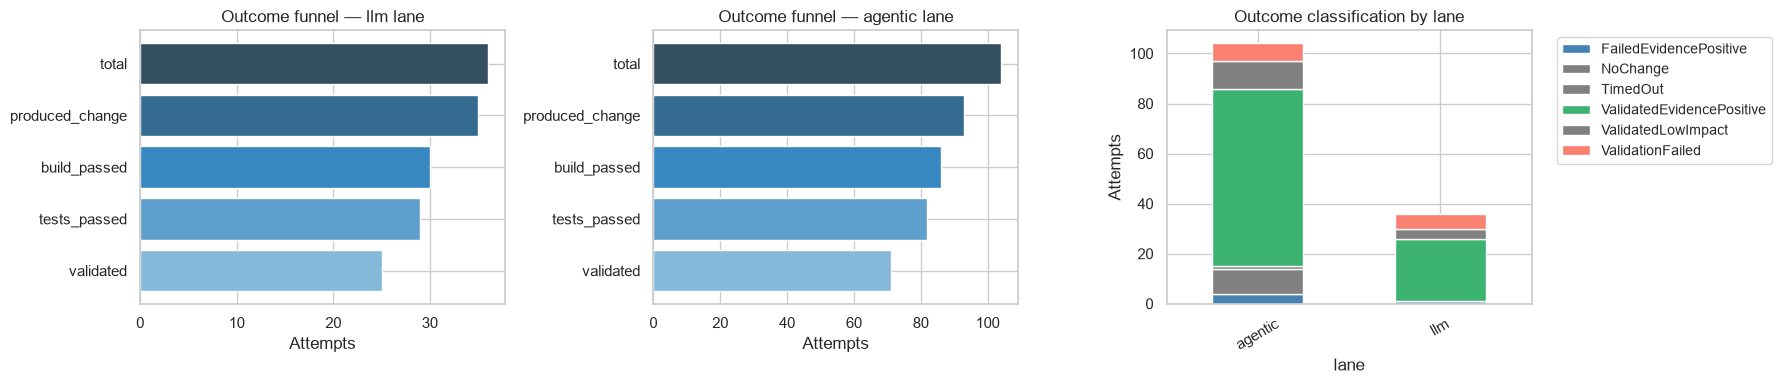

chains           %      
lane                      agentic llm agentic   llm
outcome_classification                             
FailedEvidencePositive          4   1     3.8   2.8
NoChange                       10   0     9.6   0.0
TimedOut                        1   0     1.0   0.0
ValidatedEvidencePositive      71  25    68.3  69.4
ValidatedLowImpact             11   4    10.6  11.1
ValidationFailed                7   6     6.7  16.7

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
outcome_funnel(A, lane='llm', ax=axes[0])
outcome_funnel(A, lane='agentic', ax=axes[1])
outcome_classification_bar(A, group_col='lane', ax=axes[2])
plt.tight_layout()
plt.show()

counts = A.groupby(['outcome_classification', 'lane']).size().unstack(fill_value=0)
display(pd.concat({'chains': counts, '%': counts.div(counts.sum()).mul(100).round(1)}, axis=1))

### How the lanes fail

The two lanes reach not-VEP by different routes: an invalid test (compile, execute or
assert failure) versus an attempt that changed nothing or ran out of time. A single
success rate hides that difference, so the shares are reported side by side.

Counted per chain at its final outcome. Counting every repair step instead would give the
LLM lane one failure per retry, so a chain that fails four times and then succeeds would
look like four failures and one success; the agentic lane runs once per chain and would
not pay that penalty.

In [6]:
final = A  # already one row per chain
modes = (final.groupby(['outcome_classification', 'lane']).size()
         .unstack(fill_value=0))
shares = modes.div(modes.sum()).mul(100).round(1)
display(pd.concat({'chains': modes, '% of evaluable chains': shares}, axis=1))

llm_failed = final[(final['lane'] == 'llm')
                   & (final['outcome_classification'] == 'ValidationFailed')]
if len(llm_failed) and 'failure_kind' in llm_failed:
    print('LLM chains ending in validation failure, by kind and stage:')
    display(llm_failed.groupby(['failure_kind', 'failure_stage']).size().rename('chains'))

chains     % of evaluable chains      
lane                      agentic llm               agentic   llm
outcome_classification                                           
FailedEvidencePositive          4   1                   3.8   2.8
NoChange                       10   0                   9.6   0.0
TimedOut                        1   0                   1.0   0.0
ValidatedEvidencePositive      71  25                  68.3  69.4
ValidatedLowImpact             11   4                  10.6  11.1
ValidationFailed                7   6                   6.7  16.7

LLM chains ending in validation failure, by kind and stage:


failure_kind  failure_stage
Compilation   build            5
Generation    application      1
Name: chains, dtype: int64

## Metric movement

Coverage is a 0-1 fraction; mutation score is 0-100.

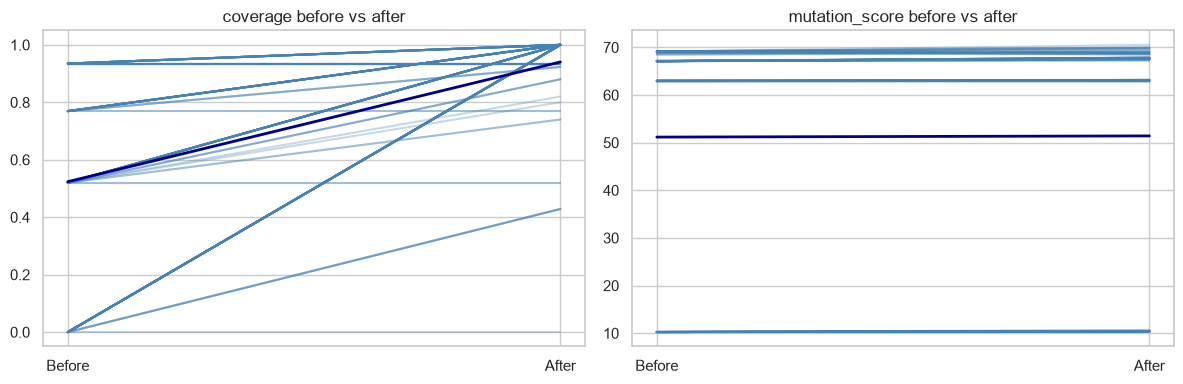

lines_closed               mutants_newly_killed              
               count    sum median                count    sum median
lane                                                                 
agentic           87  902.0    7.0                   87  227.0    1.0
llm               30  240.0    5.0                   30   40.0    0.0

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before_after_slope(A, 'coverage_before', 'coverage_after', ax=axes[0])
before_after_slope(A, 'mutation_score_before', 'mutation_score_after', ax=axes[1])
plt.tight_layout()
plt.show()

# Set differences against the target member: baseline gap lines closed, baseline survivors killed.
diff_cols = [c for c in ['lines_closed', 'mutants_newly_killed'] if c in A.columns]
if diff_cols:
    display(A.groupby('lane')[diff_cols].agg(['count', 'sum', 'median']))

## Generated tests

,tests_per_attempt,max_per_attempt,tests
lane,,,
agentic,6.78,34,563
llm,1.00,1,54


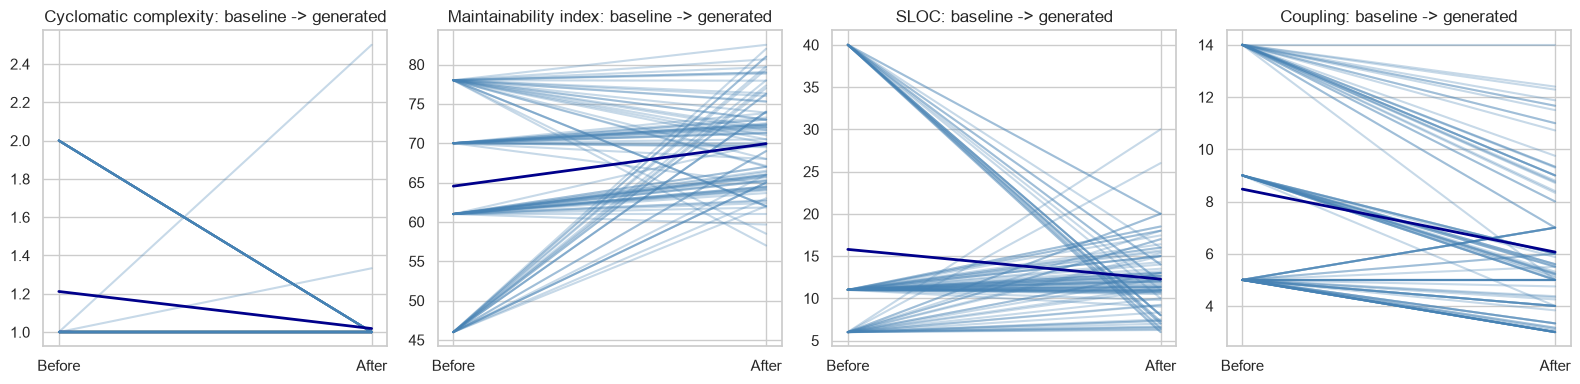

,baseline_test_cc,generated_test_cc,baseline_test_mi,generated_test_mi,baseline_test_sloc,generated_test_sloc,baseline_test_coupling,generated_test_coupling
lane,,,,,,,,
agentic,1.0,1.0,70.0,70.88,11.0,11.33,7.0,5.41
llm,1.0,1.0,65.5,67.00,11.0,14.00,9.0,5.00


In [8]:
if not T.empty:
    per_attempt = T.groupby(['lane', 'attempt_id']).size()
    display(per_attempt.groupby('lane').agg(['mean', 'max', 'sum'])
            .rename(columns={'mean': 'tests_per_attempt', 'max': 'max_per_attempt', 'sum': 'tests'})
            .round(2))

metric_pairs = [
    ('baseline_test_cc', 'generated_test_cc', 'Cyclomatic complexity'),
    ('baseline_test_mi', 'generated_test_mi', 'Maintainability index'),
    ('baseline_test_sloc', 'generated_test_sloc', 'SLOC'),
    ('baseline_test_coupling', 'generated_test_coupling', 'Coupling'),
]
metric_pairs = [p for p in metric_pairs if p[0] in A.columns and p[1] in A.columns]
fig, axes = plt.subplots(1, len(metric_pairs), figsize=(4 * len(metric_pairs), 4), squeeze=False)
for ax, (before_col, after_col, label) in zip(axes[0], metric_pairs):
    before_after_slope(A, before_col, after_col, ax=ax)
    ax.set_title(f'{label}: baseline -> generated')
plt.tight_layout()
plt.show()
display(A.groupby('lane')[[c for pair in metric_pairs for c in pair[:2]]].median().round(2))

## Test smells

,n,mean_smells,median_smells
tests,,,
baseline (one example test per method),4,1.50,1.0
generated (one row per generated test),617,1.43,1.0


,count,mean,median
lane,,,
agentic,83,1.49,1.5
llm,36,1.75,2.0


,count,mean,median
lane,,,
agentic,563,1.41,1.0
llm,54,1.65,2.0


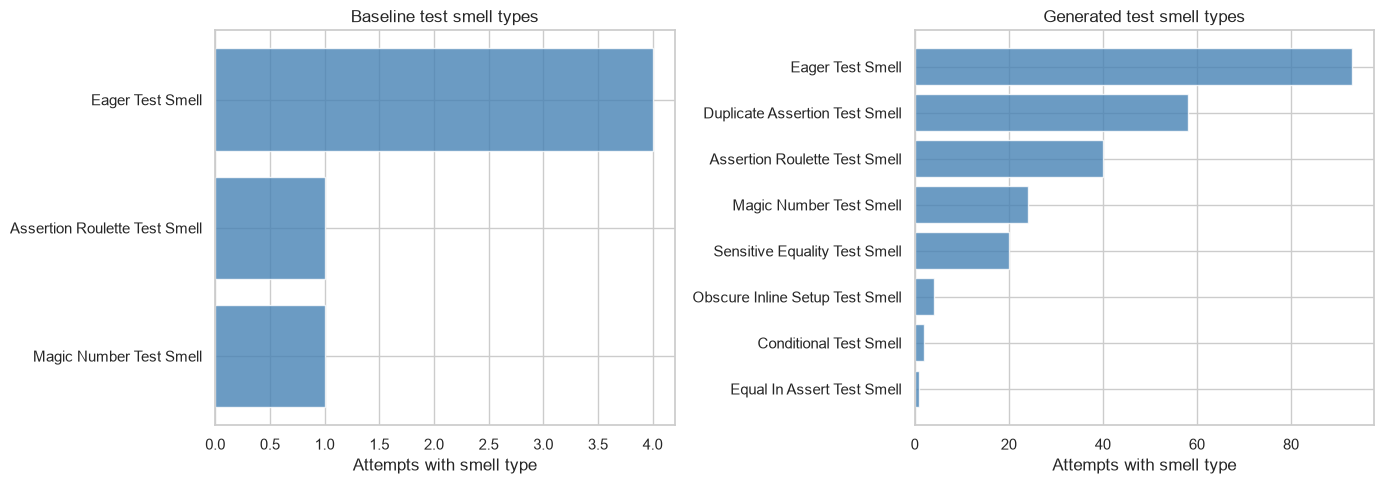

In [9]:
# The baseline test belongs to the candidate method, so it is counted once per method.
baseline = A.drop_duplicates('candidate_key')
produced = A[A['generated_test_count'].fillna(0) > 0].assign(
    smells_per_test=lambda d: d['generated_test_smell_count'] / d['generated_test_count'])
# Per test, not per attempt: an agentic attempt can write several tests, so its
# attempt-level smell count is a batch total and is not comparable to one baseline test.
rows = [{'tests': 'baseline (one example test per method)',
         'n': int(baseline['baseline_test_smell_count'].notna().sum()),
         'mean_smells': baseline['baseline_test_smell_count'].mean(),
         'median_smells': baseline['baseline_test_smell_count'].median()}]
if len(gen_tests) and 'generated_test_smell_count' in gen_tests:
    per_test = gen_tests['generated_test_smell_count']
    rows.append({'tests': 'generated (one row per generated test)', 'n': int(per_test.notna().sum()),
                 'mean_smells': per_test.mean(), 'median_smells': per_test.median()})
display(pd.DataFrame(rows).set_index('tests').round(2))

# Attempt-derived view, kept as a cross-check of the per-test figure above.
display(produced.groupby('lane')['smells_per_test'].agg(['count', 'mean', 'median']).round(2))
if len(gen_tests) and {'lane', 'generated_test_smell_count'} <= set(gen_tests.columns):
    display(gen_tests.groupby('lane')['generated_test_smell_count']
            .agg(['count', 'mean', 'median']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
smell_type_breakdown(baseline, 'baseline_test_smell_types', ax=axes[0])
axes[0].set_title('Baseline test smell types')
smell_type_breakdown(produced, 'generated_test_smell_types', ax=axes[1])
axes[1].set_title('Generated test smell types')
plt.tight_layout()
plt.show()

## Assertions

In [10]:
validated = A[A['validated_success'] == True]
measured = validated[validated['recognized_assertion_count'].notna()]
print(f'Validated successes: {len(validated)}; assertion-measured: {len(measured)}; '
      f'zero recognized assertions: {int((measured["recognized_assertion_count"] == 0).sum())}')
unmeasured = validated[validated['recognized_assertion_count'].isna()]
if len(unmeasured):
    display(unmeasured.groupby(['lane', 'assertion_measurement_status', 'assertion_measurement_reason'],
                               dropna=False).size().rename('unmeasured validated successes'))
display(A.groupby('lane')['recognized_assertion_count'].agg(['count', 'median', 'min', 'max']))

Validated successes: 111; assertion-measured: 103; zero recognized assertions: 0


lane     assertion_measurement_status  assertion_measurement_reason 
agentic  Unavailable                   GeneratedTestMemberUnresolved    8
Name: unmeasured validated successes, dtype: int64

,count,median,min,max
lane,,,,
agentic,83,12.0,1.0,60.0
llm,30,3.0,1.0,7.0


## Baseline mutation profile

In [11]:
profiled = set(M['repository_key']) if not M.empty else set()
missing_profile = sorted(set(A['repository_key']) - profiled)
if missing_profile:
    print(f'No solution-scope baseline mutation report: {missing_profile}')
if not M.empty:
    m = M.assign(killable=M[['Killed', 'Survived']].fillna(0).sum(axis=1))
    display(m[m['killable'] >= 5].sort_values('survival_rate', ascending=False)
            [['repository_key', 'mutation_testing_report_id', 'mutator_name', 'Killed', 'Survived', 'survival_rate']].head(12))
    by_repo = m.groupby(['repository_key', 'mutation_testing_report_id'])[['Killed', 'Survived']].sum()
    display(by_repo.assign(survival_rate=by_repo['Survived'] / by_repo.sum(axis=1)).round(3))

No solution-scope baseline mutation report: ['alirezanet/gridify|2d6b9b3fe66f02a448eb5065fc3acdd0d74dd5da']


,repository_key,mutation_testing_report_id,mutator_name,Killed,Survived,survival_rate
4,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Array initializer mutation,0,9,1.000000
23,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,MultiplyAssignmentExpression to DivideAssignme...,0,5,1.000000
61,dotnetcore/aspectcore-framework|d8fa5ca2d16cb9...,1,Linq method mutation (Single() to SingleOrDefa...,0,6,1.000000
91,serilog/serilog-expressions|697c8fa89ec167b1f3...,1,Linq method mutation (Concat() to Except()),1,7,0.875000
36,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,String mutation,10,55,0.846154
9,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,Conditional (false) mutation,2,9,0.818182
49,dotnetcore/aspectcore-framework|d8fa5ca2d16cb9...,1,Linq method mutation (All() to Any()),1,4,0.800000
75,dotnetcore/aspectcore-framework|d8fa5ca2d16cb9...,1,UnaryMinusExpression to UnaryPlusExpression mu...,2,5,0.714286
59,dotnetcore/aspectcore-framework|d8fa5ca2d16cb9...,1,Linq method mutation (OrderByDescending() to O...,2,4,0.666667
22,cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36...,1,LogicalNotExpression to un-LogicalNotExpressio...,12,24,0.666667


,,Killed,Survived,survival_rate
repository_key,mutation_testing_report_id,,,
cysharp/zstring|e2b86f7ad433dd7dba2ac0b1a66d36f5105aa912,1,1124,342,0.233
dotnetcore/aspectcore-framework|d8fa5ca2d16cb90481586369abc1f19f97946ac4,1,2751,670,0.196
serilog/serilog-expressions|697c8fa89ec167b1f3f9457c8cee500ad02e8bc2,1,1210,355,0.227


## Agentic change footprint

In [12]:
agentic = A[A['lane'] == 'agentic']
footprint_cols = [c for c in ['changed_files_count', 'test_files_changed', 'production_files_changed',
                              'project_files_changed', 'deleted_files_count'] if c in agentic.columns]
display(agentic[footprint_cols].describe().T.round(2))
if 'production_files_changed' in agentic.columns:
    rate = agentic.groupby('tool_id')['production_files_changed'].apply(lambda s: (s.fillna(0) > 0).mean())
    print(f'Tools that changed production files: {int((rate > 0).sum())}/{len(rate)}')
    if (rate > 0).any():
        display(rate[rate > 0].round(3).rename('production_change_rate'))
display(agentic.groupby('validated_success')['changed_files_count'].describe().round(2))

,count,mean,std,min,25%,50%,75%,max
changed_files_count,104.0,1.30,0.91,0.0,1.0,1.0,1.0,4.0
test_files_changed,104.0,0.87,0.40,0.0,1.0,1.0,1.0,2.0
production_files_changed,104.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
project_files_changed,104.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
deleted_files_count,104.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0


Tools that changed production files: 0/27


,count,mean,std,min,25%,50%,75%,max
validated_success,,,,,,,,
False,22.0,1.09,1.41,0.0,0.0,0.5,1.75,4.0
True,82.0,1.35,0.73,1.0,1.0,1.0,1.00,3.0


## Cost and runtime

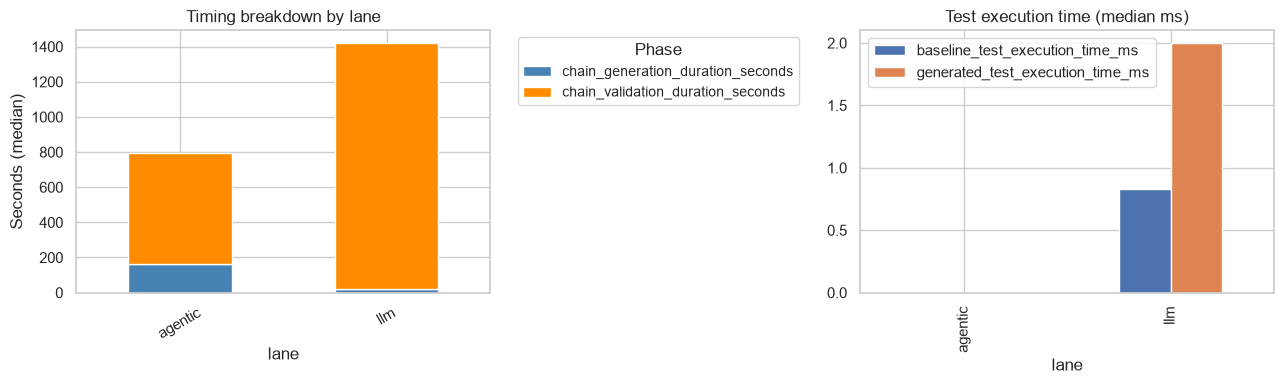

,count,median,sum
lane,,,
agentic,104,904.2,143264.2
llm,36,1424.2,94037.8


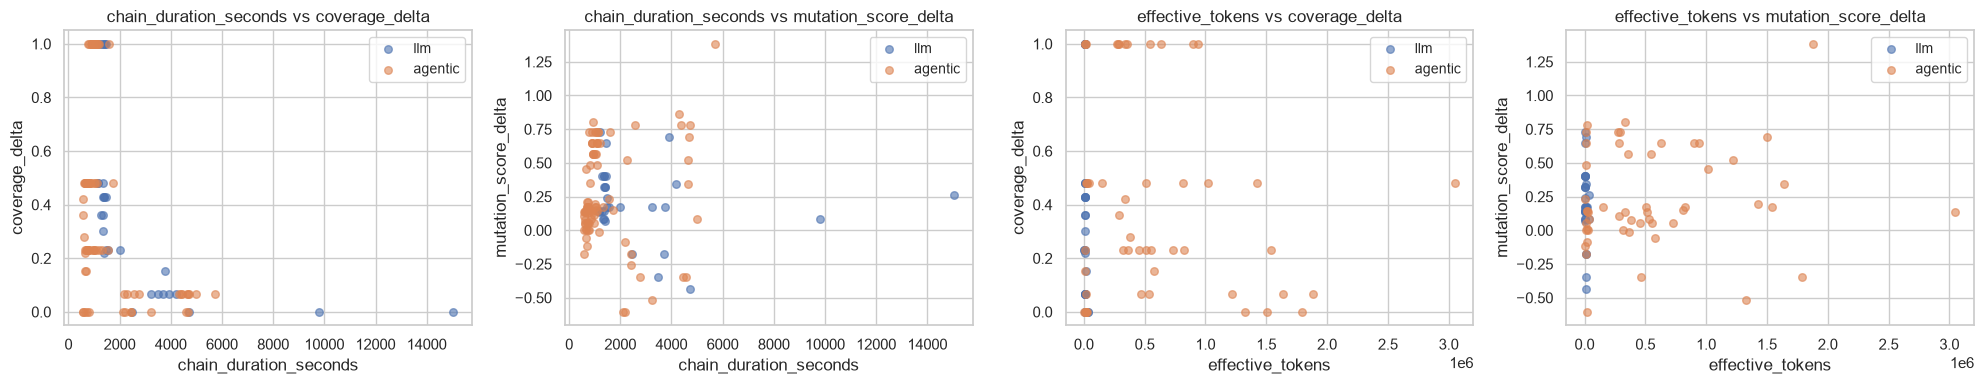

count         sum    median
lane    budget_mode                                  
agentic PassAt1              57  29612182.0  336935.0
llm     PassAt1              18    139185.0    7287.0
        PassAt1RepairAt5     18    255540.0    7925.0

usage_status,complete-estimated,complete-reported,missing,partial
lane,,,,
agentic,0,57,51,0
llm,54,0,24,14


No recorded usage: mini-swe-agent-anthropic, mini-swe-agent-custom-glm, mini-swe-agent-custom-gpt, mini-swe-agent-custom-kimi, mini-swe-agent-gemini, mini-swe-agent-openai, openhands-anthropic, openhands-custom-glm, openhands-custom-gpt, openhands-custom-kimi, openhands-gemini, openhands-openai


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
timing_stacked_bar(A, group_col='lane', gen_col='chain_generation_duration_seconds',
                   val_col='chain_validation_duration_seconds', ax=axes[0])
exec_cols = ['baseline_test_execution_time_ms', 'generated_test_execution_time_ms']
A.groupby('lane')[exec_cols].median().plot(kind='bar', ax=axes[1], title='Test execution time (median ms)')
plt.tight_layout()
plt.show()
# Chain time: all repair steps together.
display(A.groupby('lane')['chain_duration_seconds'].agg(['count', 'median', 'sum']).round(1))

pairs = [(x, y) for x in ('chain_duration_seconds', 'effective_tokens')
         for y in ('coverage_delta', 'mutation_score_delta')]
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
for ax, (x, y) in zip(axes, pairs):
    cost_vs_improvement_scatter(A, x, y, 'lane', ax=ax)
    ax.set_title(f'{x} vs {y}')
plt.tight_layout()
plt.show()

# Chain cost: LLM terminal cumulative tokens, agentic run total. Chains without usage are left out.
display(C[C['effective_tokens'].notna()].groupby(['lane', 'budget_mode'])['effective_tokens']
        .agg(['count', 'sum', 'median']))
display(pd.crosstab(ALL['lane'], ALL['usage_status']))
no_usage = ALL.groupby('producer')['usage_status'].apply(lambda s: s.eq('missing').all())
if no_usage.any():
    print(f'No recorded usage: {", ".join(no_usage[no_usage].index)}')

## Data completeness

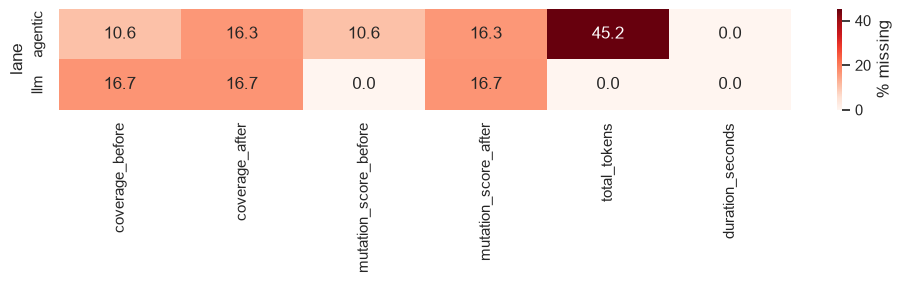

In [14]:
key_cols = [c for c in ['coverage_before', 'coverage_after', 'mutation_score_before',
                        'mutation_score_after', 'total_tokens', 'duration_seconds'] if c in A.columns]
null_pct = A.groupby('lane')[key_cols].apply(lambda g: g.isna().mean() * 100)
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(null_pct, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': '% missing'})
plt.tight_layout()
plt.show()